# Gaussian Process

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
np.random.seed(42)
%matplotlib inline

In [2]:
def R(x, theta=0.08):
    return np.exp(-x**2/theta**2)


def k(x,y, tau=1, theta=0.08):
    return (tau**2)*R(x-y, theta)

In [3]:
x=np.linspace(0,1,100)
mean_vector=np.zeros(len(x))

In [4]:
K=np.zeros([len(x),len(x)])

K.shape

(100, 100)

In [5]:
for i in range(len(x)):
    for j in range(len(x)):
        K[i][j]=k(x[i], x[j])
factor=1e-10
K=K+factor*np.eye(len(K))
L=np.linalg.cholesky(K)

In [6]:
Ls=[]
zs=[]
hs=[]
fig, ax=plt.subplots()

curves=6

for curve in range(curves):    
    z=np.random.randn(len(x))
    h_sample=mean_vector+L@z
    zs.append(z)
    hs.append(h_sample)
    ax.plot(x, h_sample)
    

In [7]:
x_observed=np.random.rand(10)
sigma=0.002
noise=sigma*np.random.randn(10)
xs=[x_observed**4, x_observed**3, x_observed**2, x_observed, x_observed**0]
xs=np.array(xs)
coeffs=np.random.randint(low=-5, high = 5, size=5)
y_real=coeffs@xs+noise
print(coeffs)
x_observed
xs

[-2 -1  2 -1  2]


array([[0.00276215, 0.27211744, 0.26879311, 0.16897878, 0.23190431,
        0.0867596 , 0.00401991, 0.01428162, 0.00108753, 0.68109108],
       [0.01204858, 0.37676217, 0.37330482, 0.26355674, 0.3341809 ,
        0.15985939, 0.01596476, 0.04131265, 0.00598868, 0.74972828],
       [0.0525562 , 0.52164877, 0.51845261, 0.41107029, 0.48156444,
        0.29454982, 0.06340277, 0.11950572, 0.03297773, 0.82528242],
       [0.2292514 , 0.72225257, 0.72003654, 0.64114763, 0.69394844,
        0.54272444, 0.25179906, 0.34569599, 0.18159772, 0.90845056],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ]])

In [8]:
ax.scatter(x_observed, y_real)

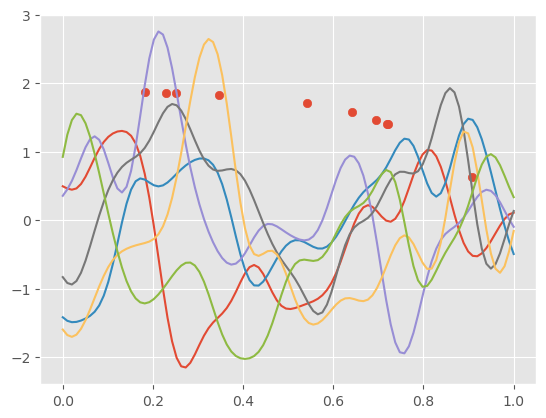

In [9]:
plt.show()

In [10]:
def r(x_predict, x_obs=x_observed, theta=0.08):
    r_x=np.zeros([len(x_predict), len(x_obs)])
    # print(r_x.shape)
    for i, x in enumerate(x_predict):
        for j, y in enumerate(x_obs):
            # print(i,j)
            # print(R(i-j))
            r_x[i][j]=R(x-y, theta)

    return r_x
            
r_posterior=r(x)


In [11]:
R_posterior=np.zeros([len(x_observed),len(x_observed)])
for i, x1 in enumerate(x_observed):
    for j, x2 in enumerate(x_observed):
        R_posterior[i][j]=R(x1-x2)
R_posterior.shape


(10, 10)

In [12]:
R_posterior_inv=np.linalg.inv(R_posterior+factor*np.eye(len(R_posterior)))
posterior_mean=mean_vector+r_posterior@R_posterior_inv@(y_real)

In [13]:
R__=np.zeros([len(x), len(x)])

for i,x1 in enumerate(x):
    for j, x2 in enumerate(x):
        R__[i][j]=R(x1-x2)

In [14]:
posterior_cov=(R__)-r_posterior@R_posterior_inv@r_posterior.T
posterior_cov_jitters=posterior_cov+factor*np.eye(len(posterior_cov))*1e3

In [15]:
L_posterior=np.linalg.cholesky(posterior_cov_jitters)

In [16]:

zs_posterior=[]
hs_posterior=[]
fig2, ax2=plt.subplots()

curves=6

for curve in range(curves):    
    z_posterior=np.random.randn(len(x))
    h_sample_posterior=posterior_mean+L_posterior@z_posterior
    zs_posterior.append(z)
    hs_posterior.append(h_sample)
    ax2.plot(x, h_sample_posterior,label=curve)
ax2.scatter(x_observed, y_real)


sigma=0.2
noise=sigma*np.random.randn(10)
xs_grid=[x**4, x**3, x**2, x, x**0]
xs_grid=np.array(xs_grid)

y_real_no_noise=coeffs@xs_grid

ax2.plot(x,y_real_no_noise, label="real_function", linestyle="--")
ax2.legend()


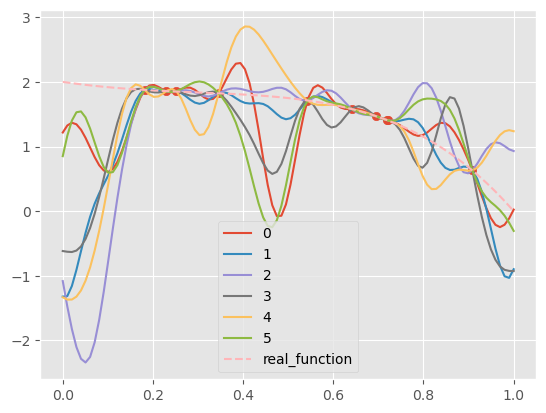

In [17]:
plt.show()

# Linear Regression


In [18]:
x_data=np.random.rand(10)
x_data_F=x_data.copy()
sigma=0.5
y1=2*np.sin(2*np.pi*x_data)+sigma*np.random.randn(len(x_data))
y2=2*np.sin(2*np.pi*x_data)+sigma*np.random.randn(len(x_data))

x_data=np.repeat(x_data,2)
x_data.reshape(-1)
x_data.shape
y=np.column_stack((y1,y2))

y=y.reshape(-1)
y

array([ 1.23346782, -0.00456806, -1.11656688, -1.56241039, -0.64513828,
        1.04330493,  1.05471434,  2.11656484, -1.2355504 , -1.93976655,
       -1.98382288, -1.97707546,  2.32634442,  0.95727572, -1.22617253,
       -1.78352793, -2.24028633, -1.98596856,  2.09396144,  2.04794718])

In [19]:
x_grid=np.linspace(0,1,100)
y_grid=2*np.sin(2*np.pi*x_grid)

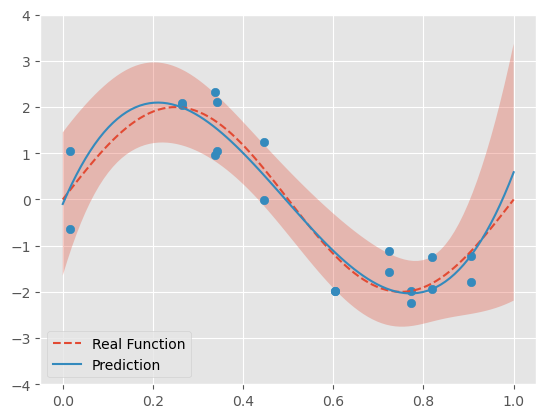

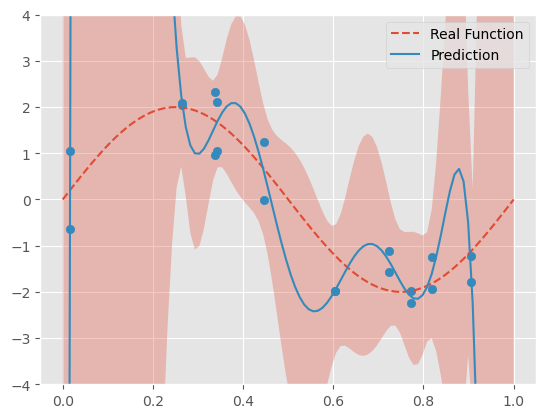

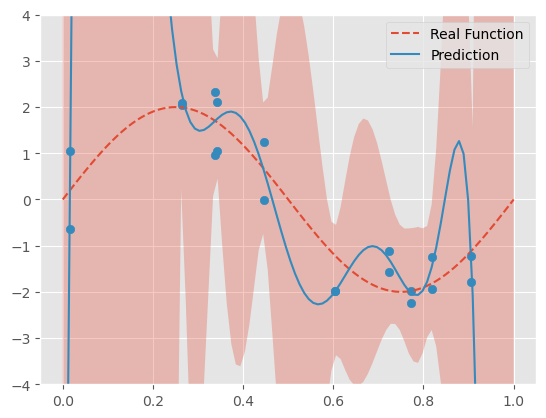

In [20]:
degrees=[3,8,9]
for degree in degrees:
    X=[]
    for i in range(degree+1):
        X.append(x_data**i)
    X=np.array(X)
    X=X.T
    
    beta_hat=np.linalg.inv((X.T@X))@X.T@y
    X_grid=[]
    for i in range(degree+1):
        X_grid.append(x_grid**i)
    X_grid=np.array(X_grid)
    X_grid=X_grid.T
    
    beta_std=np.sqrt(np.diag(X_grid@np.linalg.inv(X.T@X)@X_grid.T))
    
    y_pred=X_grid@beta_hat
    
    fig, ax=plt.subplots()
    ax.plot(x_grid, y_grid, linestyle="--", label="Real Function")
    ax.plot(x_grid, y_pred, label="Prediction")
    ax.fill_between(
        x_grid, 
        y_pred+2*beta_std,
        y_pred-2*beta_std,
        alpha=0.3
    )
    ax.scatter(x_data, y)
    ax.legend()
    ax.set_ylim(-4,4)
    plt.show()

## Fedorov Exchange Algorithm

In [21]:
def LinearRegression(x_data, y, x_grid, y_grid, degree):
    X=[]
    for i in range(degree+1):
        X.append(x_data**i)
    X=np.array(X)
    X=X.T
    
    beta_hat=np.linalg.inv((X.T@X))@X.T@y
    X_grid=[]
    for i in range(degree+1):
        X_grid.append(x_grid**i)
    X_grid=np.array(X_grid)
    X_grid=X_grid.T
    
    beta_std=np.sqrt(np.diag(X_grid@np.linalg.inv(X.T@X)@X_grid.T))
    
    y_pred=X_grid@beta_hat
    
    fig, ax=plt.subplots()
    ax.plot(x_grid, y_grid, linestyle="--", label="Real Function")
    ax.plot(x_grid, y_pred, label="Prediction")
    ax.fill_between(
        x_grid, 
        y_pred+2*beta_std,
        y_pred-2*beta_std,
        alpha=0.3
    )
    ax.scatter(x_data, y)
    ax.legend()
    ax.set_ylim(-4,4)
    plt.show()

In [22]:
candidate_set=np.linspace(0,1,301)

In [23]:
candidate_set.shape

(301,)

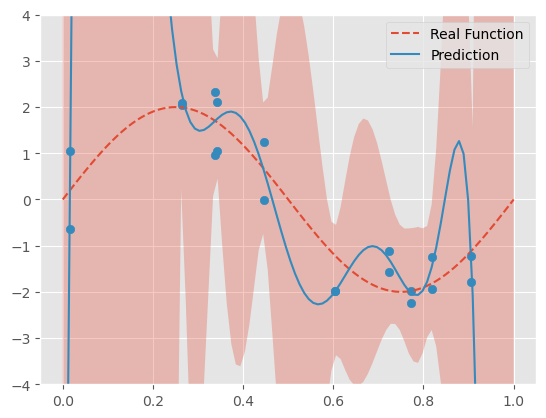

In [24]:
LinearRegression(x_data, y, x_grid, y_grid, 9)

In [25]:
def InversMatrix(x, degree):
    X=[]
    for i in range(degree+1):
        X.append(x**i)
    X=np.array(X)
    X=X.T
    return np.linalg.inv(X.T@X)

In [26]:
def delta(x,c, inverse):
    x_vec=np.array([x**i for i in range(len(inverse))])
    c_vec=np.array([c**i for i in range(len(inverse))])
    cal=c_vec.T@inverse@c_vec-(x_vec.T@inverse@x_vec)*(1+c_vec.T@inverse@c_vec)+(c_vec.T@inverse@x_vec)**2
    return cal

In [27]:
while(True):   
    max_delta=0
    exchange=(0,0)
    for c_i,c in enumerate(candidate_set):
        for x_i,x in enumerate(x_data_F):
            invers=InversMatrix(x_data_F, 9)
            d=delta(x,c,invers)
            if d>max_delta:
                exchange_corrdinate=(x_i, c_i)
                exchange=(x,c)
                max_delta=d
    if max_delta>0:
        x_data_F[exchange_corrdinate[0]]=exchange[1]
        candidate_set=np.delete(candidate_set,exchange_corrdinate[1])
    
    if max_delta<=0:
        break

In [28]:
candidate_set.shape
x_data_F.shape

(10,)

In [29]:
sigma=0.5
y1=2*np.sin(2*np.pi*x_data_F)+sigma*np.random.randn(len(x_data_F))
y2=2*np.sin(2*np.pi*x_data_F)+sigma*np.random.randn(len(x_data_F))

x_data_F=np.repeat(x_data_F,2)
x_data_F.reshape(-1)
x_data_F.shape
y_new=np.column_stack((y1,y2))

y_new=y_new.reshape(-1)
y_new

array([ 1.43422176,  0.54340055, -2.89406795, -2.13714375,  2.11354237,
        1.89059571,  0.84458293,  0.87942781, -0.66079792, -0.11082617,
       -1.59488077, -1.57758988,  0.62457032, -0.11829018, -1.60798424,
       -1.65613417, -0.01000945,  0.21258942,  2.18785944,  2.16388245])

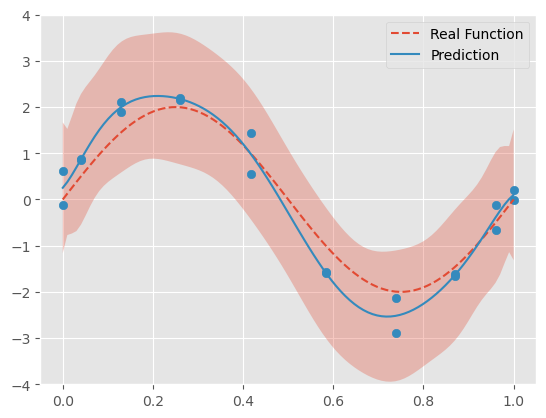

In [30]:
LinearRegression(x_data_F, y_new, x_grid, y_grid, 9)

In [31]:
y_new.shape

(20,)

In [32]:
x_data_F.shape

(20,)

# Kernel Ridge Regression

In [33]:
def K(x,y,theta):
    return np.exp((-(x-y)**2)/theta**2)
    

In [34]:
def Kernel(x,y,theta):
    output=np.zeros([len(x), len(y)])
    for x_i, i in enumerate(x):
        for y_i, j in enumerate(y):
            output[x_i][y_i]=K(i,j,theta)
    return output
            

In [35]:
def h(x):
    return np.sin(10*np.pi*x)/(1+64*(x-0.25)**2)+x**2

In [36]:
def mscv(y_observed, big_K, lam):
    inverse=np.linalg.inv(big_K+lam*np.eye(len(big_K)))
    cv = ((inverse)@y_observed)/np.diag(inverse)
    mscv= np.average(cv**2)
    return mscv
    

In [37]:
np.random.seed(42)
x_equispaced=np.linspace(0,1,10)
x_data=x_equispaced.copy()
sigma=0.08
y1=h(x_equispaced)+sigma*np.random.randn(len(x_equispaced))
y2=h(x_equispaced)+sigma*np.random.randn(len(x_equispaced))
x_data=np.repeat(x_data, 2)
x_data=x_data.reshape(-1,1)
x_data.shape
y=np.column_stack((y1, y2))
y=y.reshape(-1,1)
y.shape

(20, 1)

In [38]:
lam=np.linspace(0,1,100)
lam=np.delete(lam, 0)
theta=np.linspace(0,1,100)
theta=np.delete(theta, 0)

optimum=(0,0)
max_mscv=9999999
previous_error=max_mscv
error=999
while(error>1e-4):
    max_mscv=9999999
    for t_i,t in enumerate(theta):
        big_K=Kernel(x_data, x_data, t)
        for l_i,l in enumerate(lam):       
            mscv_t_l=mscv(y, big_K, l)
            if mscv_t_l<max_mscv:
                optimum=(t,l)
                max_mscv=mscv_t_l
                coordinate=(t_i, l_i)
    
    if coordinate[0]==0:
        theta=np.linspace(0, theta[coordinate[0]+1], 100)
        theta=np.delete(theta, 0)
    elif coordinate[0]==len(theta)-1 :
        theta=np.linspace(theta[coordinate[0]-1], 2*theta[coordinate[0]]-theta[coordinate[0]-1], 100)
    else:
        theta=np.linspace(theta[coordinate[0]-1], theta[coordinate[0]+1], 100)
    
    
    if coordinate[1]==0:
        lam=np.linspace(0, lam[coordinate[1]+1], 100)
        lam=np.delete(lam, 0)
    elif coordinate[1]==len(lam)-1:
        lam=np.linspace(lam[coordinate[1]-1], 2*lam[coordinate[1]]-lam[coordinate[1]-1], 100)
    else:
        lam=np.linspace(lam[coordinate[1]-1], lam[coordinate[1]+1], 100)
    
    error=np.abs(previous_error-max_mscv)
    previous_error=max_mscv


print(optimum, mscv_t_l)

(0.07948168554229161, 0.0289766350372411) 0.016638325952313536


In [39]:
K_mine=Kernel(x_data, x_data, optimum[0])
print(mscv(y, K_mine, optimum[1]))

K_book=Kernel(x_data, x_data, 0.08)
print(mscv(y, K_book, 0.036))

0.016567294313910134
0.016580932178609654


In [40]:
x_grid=np.linspace(0,1,100)
prediction_K=Kernel(x_data, x_data, optimum[0])
c_hat=np.linalg.inv(prediction_K+optimum[1]*np.eye(len(prediction_K)))@y
kernel_grid=Kernel(x_grid, x_data, optimum[0])
y_pred=kernel_grid@c_hat
y_real=h(x_grid)

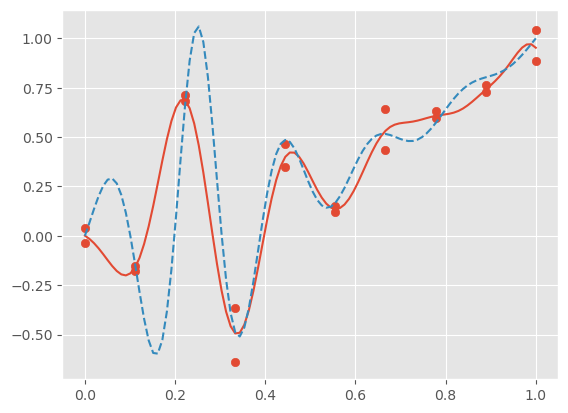

In [41]:
fig, ax= plt.subplots()
ax.plot(x_grid, y_pred)
ax.plot(x_grid, y_real, label="real Function", linestyle="--")
ax.scatter(x_data, y)
plt.show()

# Gaussian Regression

In [42]:
def Big_R(x,y,theta):
    output=np.zeros([len(x), len(y)])
    for x_i, i in enumerate(x):
        for y_j,j in enumerate(y):
            output[x_i][y_j]=k(i,j,theta=theta)

    return output
        
    

In [43]:
candidate_theta=np.linspace(0,10,100)
candidate_theta=np.delete(candidate_theta, 0)
candidate_lam=np.linspace(0,10,100)
candidate_lam=np.delete(candidate_lam, 0)
print(error)

7.137231524921572e-07


In [44]:
#error=np.inf
previous_error=np.inf
while(error>1e-3):
    min_optimum=np.inf
    
    for t_i,t in enumerate(candidate_theta):
        R_t=Big_R(x_data, x_data, t)
        for l_i, l in enumerate(candidate_lam):
            inverse=np.linalg.inv(R_t+l*np.eye(len(R_t)))
            miu_estimate=np.sum(inverse@y)/np.sum(inverse)
            tau_estimate=(1/len(y))*(y-miu_estimate).T@inverse@(y-miu_estimate)
            optimum_criteria=len(y)*np.log(tau_estimate)+np.log(np.linalg.det(R_t+l*np.eye(len(R_t))))
            if optimum_criteria<min_optimum:
                min_optimum=optimum_criteria
                optimum=(t,l)
                coordinate=(t_i, l_i)
    if coordinate[0]==0:
        candidate_theta=np.linspace(0, candidate_theta[coordinate[0]+1], 100)
        candidate_theta=np.delete(candidate_theta, 0)
    elif coordinate[0]==len(candidate_theta)-1 :
        candidate_theta=np.linspace(candidate_theta[coordinate[0]-1], 2*candidate_theta[coordinate[0]]-candidate_theta[coordinate[0]-1], 100)
    else:
        candidate_theta=np.linspace(candidate_theta[coordinate[0]-1], candidate_theta[coordinate[0]+1], 100)
    
    
    if coordinate[1]==0:
        candidate_lam=np.linspace(0, candidate_lam[coordinate[1]+1], 100)
        candidate_lam=np.delete(candidate_lam, 0)
    elif coordinate[1]==len(candidate_lam)-1:
        candidate_lam=np.linspace(candidate_lam[coordinate[1]-1], 2*candidate_lam[coordinate[1]]-candidate_lam[coordinate[1]-1], 100)
    else:
        candidate_lam=np.linspace(candidate_lam[coordinate[1]-1], candidate_lam[coordinate[1]+1], 100)
        
        error=np.abs(previous_error-min_optimum)
        previous_error=min_optimum
        

In [45]:
optimum


(0.07948168554229161, 0.0289766350372411)

In [46]:
finalR=Big_R(x_data, x_data, theta=optimum[0])
inverse=np.linalg.inv(finalR+optimum[1]*np.eye(len(finalR)))
final_miu=np.sum(inverse@y)/np.sum(inverse)
final_tau=(1/len(y))*(y-final_miu).T@inverse@(y-final_miu)
small_r=r(x_grid, x_data, optimum[0])
y_grid=(final_miu+small_r@inverse@(y-final_miu)).reshape(-1)
var=((final_tau)*(1+optimum[1]-np.diag(small_r@inverse@small_r.T))).reshape(-1)

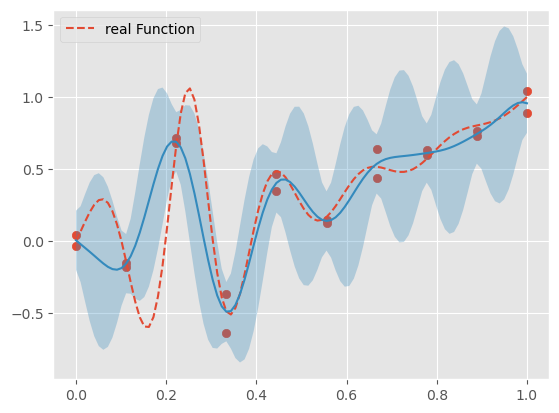

In [47]:
fig, ax=plt.subplots()
ax.plot(x_grid, y_real, label="real Function", linestyle="--")
ax.plot(x_grid, y_grid)
ax.scatter(x_data, y)
ax.fill_between(
    x_grid, 
    y_grid+2*np.sqrt(var.T),
    y_grid-2*np.sqrt(var.T),
    alpha=0.3
)
ax.legend()

plt.show()

In [48]:
x_grid.shape

(100,)